In [32]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import xgboost as xgb

warnings.filterwarnings('ignore')


In [33]:

# ===============================
# CONFIGURATION
# ===============================

DATASET_PATH = r"C:\Users\Rathish BN\Desktop\ML_dataset_project\Machine Learning Dataset\IMU DATASET"
TERRAINS = ["ASPHALT", "CONCRETE", "DIRT_ROAD", "PLOUGHED", "UNPLOUGHED"]
WINDOW_SIZE = 400
STRIDE = 200
RANDOM_STATE = 42

# Validate dataset path
if not os.path.isdir(DATASET_PATH):
    raise FileNotFoundError(f"Dataset path not found: {DATASET_PATH}")

# ===============================
# FEATURE EXTRACTION FUNCTION
# ===============================

def extract_features(window):
    """
    Extract statistical and physical features from IMU data window.
    
    Parameters:
    -----------
    window : np.ndarray
        Shape (WINDOW_SIZE, 6) with columns: [wx, wy, wz, ax, ay, az]
        wx, wy, wz: Angular velocities (gyroscope)
        ax, ay, az: Linear accelerations (accelerometer)
    
    Returns:
    --------
    np.ndarray
        Feature vector with 43 features total
    """
    
    if window.shape[0] != WINDOW_SIZE or window.shape[1] != 6:
        raise ValueError(f"Invalid window shape: expected ({WINDOW_SIZE}, 6), got {window.shape}")
    
    features = []
    
    # Extract 7 statistical features for each of 6 sensor axes
    # Total: 6 axes × 7 features = 42 features
    for i in range(window.shape[1]):
        sig = window[:, i]
        
        features.extend([
            np.mean(sig),                    # Mean
            np.std(sig),                     # Std Dev
            np.sqrt(np.mean(sig**2)),        # RMS
            np.min(sig),                     # Min
            np.max(sig),                     # Max
            skew(sig),                       # Skewness
            kurtosis(sig)                    # Kurtosis
        ])
    
    # Physics-inspired feature: Z-axis acceleration energy
    az_energy = window[:, 5] ** 2
    features.append(np.mean(az_energy))
    
    return np.array(features)



In [34]:

# ===============================
# DATA LOADING
# ===============================

def load_imu_data(dataset_path, terrains, window_size, stride):
    """
    Load IMU data from folder structure and extract windowed features.
    """
    
    X_all = []
    y_all = []
    
    label_map = {name: idx for idx, name in enumerate(terrains)}
    print("=" * 60)
    print("TERRAIN LABEL MAPPING")
    print("=" * 60)
    for name, idx in label_map.items():
        print(f"{idx}: {name}")
    
    file_count = 0
    window_count = 0
    
    for terrain in terrains:
        
        folder = os.path.join(dataset_path, terrain)
        label = label_map[terrain]
        
        print(f"\n{'='*60}")
        print(f"Reading terrain: {terrain}")
        print(f"{'='*60}")
        
        if not os.path.isdir(folder):
            print(f"⚠️  Folder not found: {folder}")
            continue
        
        terrain_files = 0
        terrain_windows = 0
        
        for file in os.listdir(folder):
            
            if not file.startswith("imu_"):
                continue
            
            if not (file.endswith(".csv") or file.endswith(".xlsx") or file.endswith(".xls")):
                continue
            
            path = os.path.join(folder, file)
            
            try:
                if file.endswith(".csv"):
                    imu = pd.read_csv(path)
                else:
                    imu = pd.read_excel(path)
                
            except Exception as e:
                print(f"  ⚠️  Error reading {file}: {e}")
                continue
            
            required_cols = ["wx", "wy", "wz", "ax", "ay", "az"]
            
            if not set(required_cols).issubset(imu.columns):
                print(f"  ⚠️  Missing columns in {file}")
                continue
            
            imu_vals = imu[required_cols].values
            
            if len(imu_vals) < WINDOW_SIZE:
                print(f"  ⚠️  File {file} too short ({len(imu_vals)} < {WINDOW_SIZE})")
                continue
            
            file_windows = 0
            for start in range(0, len(imu_vals) - WINDOW_SIZE + 1, STRIDE):
                
                window = imu_vals[start:start + WINDOW_SIZE]
                feats = extract_features(window)
                
                X_all.append(feats)
                y_all.append(label)
                
                file_windows += 1
                window_count += 1
            
            terrain_windows += file_windows
            terrain_files += 1
            print(f"  ✓ {file}: {file_windows} windows extracted")
        
        file_count += terrain_files
        print(f"\nTerrain '{terrain}' Summary:")
        print(f"  Files processed: {terrain_files}")
        print(f"  Total windows: {terrain_windows}")
    
    print(f"\n{'='*60}")
    print("OVERALL DATA LOADING SUMMARY")
    print(f"{'='*60}")
    print(f"Total files processed: {file_count}")
    print(f"Total windows created: {window_count}")
    
    X = np.array(X_all)
    y = np.array(y_all)
    
    return X, y, label_map



In [35]:

# ===============================
# LOAD DATA
# ===============================

print("\nStarting data loading...\n")
X, y, label_map = load_imu_data(DATASET_PATH, TERRAINS, WINDOW_SIZE, STRIDE)

if len(X) == 0:
    raise ValueError("No data loaded! Check dataset path and file format.")

print(f"\nDataset shape: {X.shape}")
print(f"  Total samples: {X.shape[0]}")
print(f"  Total features: {X.shape[1]}")
print(f"  Classes: {len(TERRAINS)}")

print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for terrain_idx, count in zip(unique, counts):
    terrain_name = TERRAINS[terrain_idx]
    percentage = 100 * count / len(y)
    print(f"  {terrain_name}: {count} samples ({percentage:.1f}%)")




Starting data loading...

TERRAIN LABEL MAPPING
0: ASPHALT
1: CONCRETE
2: DIRT_ROAD
3: PLOUGHED
4: UNPLOUGHED

Reading terrain: ASPHALT
  ✓ imu_00.csv: 24 windows extracted
  ✓ imu_01.csv: 127 windows extracted
  ✓ imu_02.csv: 3 windows extracted
  ✓ imu_03.csv: 42 windows extracted
  ✓ imu_04.csv: 24 windows extracted
  ✓ imu_05.csv: 35 windows extracted
  ✓ imu_06.csv: 19 windows extracted

Terrain 'ASPHALT' Summary:
  Files processed: 7
  Total windows: 274

Reading terrain: CONCRETE
  ✓ imu_1.csv: 4 windows extracted
  ⚠️  File imu_2.csv too short (394 < 400)
  ✓ imu_3.csv: 9 windows extracted
  ✓ imu_4.csv: 2 windows extracted
  ✓ imu_5.csv: 6 windows extracted
  ✓ imu_6.csv: 4 windows extracted

Terrain 'CONCRETE' Summary:
  Files processed: 5
  Total windows: 25

Reading terrain: DIRT_ROAD
  ✓ imu_1.csv: 19 windows extracted

Terrain 'DIRT_ROAD' Summary:
  Files processed: 1
  Total windows: 19

Reading terrain: PLOUGHED
  ✓ imu_1.csv: 19 windows extracted
  ✓ imu_2.csv: 13 win

In [36]:

# ===============================
# TRAIN-TEST SPLIT
# ===============================

print(f"\n{'='*60}")
print("TRAIN-TEST SPLIT")
print(f"{'='*60}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Test set ratio: 20%")




TRAIN-TEST SPLIT
Training set: 362 samples
Test set: 91 samples
Test set ratio: 20%


In [37]:

# ===============================
# FEATURE SCALING (NORMALIZATION)
# ===============================

print(f"\n{'='*60}")
print("FEATURE SCALING")
print(f"{'='*60}")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ StandardScaler applied (mean=0, std=1)")
print(f"  Training data - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"  Test data - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")


# ===============================
# XGBOOST MODEL TRAINING
# ===============================

print(f"\n{'='*60}")
print("XGBOOST MODEL TRAINING")
print(f"{'='*60}")

xgb_model = xgb.XGBClassifier(
    # Tree parameters
    objective="multi:softprob",
    num_class=len(TERRAINS),
    n_estimators=300,  # Same as LightGBM
    max_depth=7,       # Same as LightGBM
    
    # Learning
    learning_rate=0.05,  # Same as LightGBM
    
    # Regularization
    subsample=0.7,       # Same as LightGBM
    colsample_bytree=0.7,  # Same as LightGBM
    reg_alpha=0.1,       # L1 regularization
    reg_lambda=1.0,      # L2 regularization
    
    # Other
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

print("Model hyperparameters:")
print(f"  n_estimators: 300 (same as LightGBM)")
print(f"  max_depth: 7 (same as LightGBM)")
print(f"  learning_rate: 0.05 (same as LightGBM)")
print(f"  subsample/colsample: 0.7 (same as LightGBM)")
print(f"  Regularization: L1(0.1) + L2(1.0) (same as LightGBM)")

print("\nTraining model...")
xgb_model.fit(X_train_scaled, y_train)
print("✓ Model training completed!")




FEATURE SCALING
✓ StandardScaler applied (mean=0, std=1)
  Training data - Mean: -0.000000, Std: 1.000000
  Test data - Mean: -0.006068, Std: 0.984479

XGBOOST MODEL TRAINING
Model hyperparameters:
  n_estimators: 300 (same as LightGBM)
  max_depth: 7 (same as LightGBM)
  learning_rate: 0.05 (same as LightGBM)
  subsample/colsample: 0.7 (same as LightGBM)
  Regularization: L1(0.1) + L2(1.0) (same as LightGBM)

Training model...
✓ Model training completed!


In [38]:

# ===============================
# CROSS-VALIDATION
# ===============================

print(f"\n{'='*60}")
print("CROSS-VALIDATION ANALYSIS")
print(f"{'='*60}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    xgb_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

print(f"\n5-Fold Cross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")




CROSS-VALIDATION ANALYSIS

5-Fold Cross-Validation Scores:
  Fold 1: 0.9726
  Fold 2: 0.9863
  Fold 3: 0.9722
  Fold 4: 0.9722
  Fold 5: 0.9583

Mean CV Accuracy: 0.9723 (+/- 0.0088)


In [39]:

# ===============================
# PREDICTIONS
# ===============================

print(f"\n{'='*60}")
print("PREDICTIONS")
print(f"{'='*60}")

y_pred_train = xgb_model.predict(X_train_scaled)
y_pred_test = xgb_model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Generalization Gap: {abs(train_accuracy - test_accuracy):.4f}")

if abs(train_accuracy - test_accuracy) > 0.1:
    print("\n⚠️  WARNING: Large gap indicates overfitting!")
elif abs(train_accuracy - test_accuracy) < 0.05:
    print("\n✓ Good generalization (small train-test gap)")


# ===============================
# DETAILED METRICS
# ===============================

print(f"\n{'='*60}")
print("DETAILED CLASSIFICATION REPORT (TEST SET)")
print(f"{'='*60}\n")

print(classification_report(
    y_test,
    y_pred_test,
    labels=np.arange(len(TERRAINS)),
    target_names=TERRAINS,
    zero_division=0,
    digits=4
))

# Per-class metrics
print(f"\n{'='*60}")
print("PER-CLASS PERFORMANCE SUMMARY")
print(f"{'='*60}\n")
print(f"{'Terrain':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 60)

# Calculate metrics for each class
precision_scores = precision_score(y_test, y_pred_test, labels=np.arange(len(TERRAINS)), average=None, zero_division=0)
recall_scores = recall_score(y_test, y_pred_test, labels=np.arange(len(TERRAINS)), average=None, zero_division=0)
f1_scores = f1_score(y_test, y_pred_test, labels=np.arange(len(TERRAINS)), average=None, zero_division=0)

for i, terrain in enumerate(TERRAINS):
    mask = y_test == i
    if mask.sum() == 0:
        print(f"{terrain:<15} {'N/A':<12} {'N/A':<12} {'N/A':<12}")
        continue
    
    precision = precision_scores[i]
    recall = recall_scores[i]
    f1 = f1_scores[i]
    
    print(f"{terrain:<15} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f}")




PREDICTIONS

Training Accuracy: 1.0000
Test Accuracy: 0.9670
Generalization Gap: 0.0330

✓ Good generalization (small train-test gap)

DETAILED CLASSIFICATION REPORT (TEST SET)

              precision    recall  f1-score   support

     ASPHALT     1.0000    0.9818    0.9908        55
    CONCRETE     0.8333    1.0000    0.9091         5
   DIRT_ROAD     0.7500    0.7500    0.7500         4
    PLOUGHED     1.0000    1.0000    1.0000        14
  UNPLOUGHED     0.9231    0.9231    0.9231        13

    accuracy                         0.9670        91
   macro avg     0.9013    0.9310    0.9146        91
weighted avg     0.9689    0.9670    0.9675        91


PER-CLASS PERFORMANCE SUMMARY

Terrain         Precision    Recall       F1-Score    
------------------------------------------------------------
ASPHALT         1.0000       0.9818       0.9908      
CONCRETE        0.8333       1.0000       0.9091      
DIRT_ROAD       0.7500       0.7500       0.7500      
PLOUGHED        1.0


✓ Confusion matrix saved as 'confusion_matrix_xgboost.png'


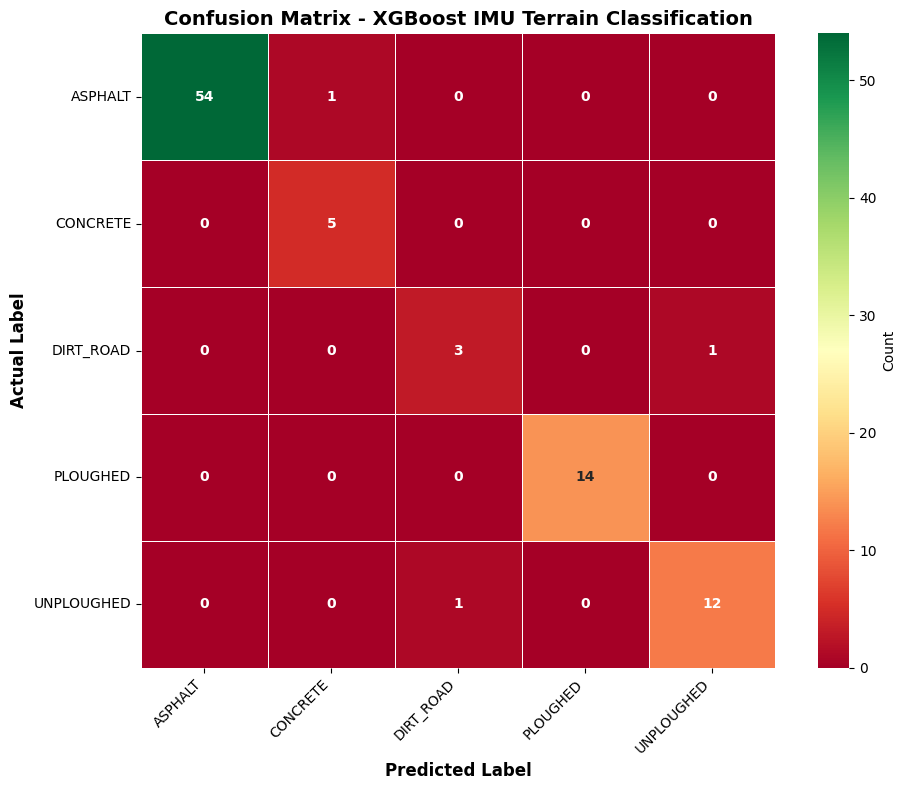


FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
  Feature  Importance
   wx_std    0.027253
   ay_max    0.028390
   wy_rms    0.028629
   ax_rms    0.031172
   wz_rms    0.031342
   wz_std    0.032361
   wx_rms    0.032515
   ax_min    0.035371
az_energy    0.037337
   ay_min    0.037760
   wy_std    0.040140
   ay_rms    0.046453
   az_rms    0.060111
   ax_std    0.092413
   ay_std    0.176813

✓ Feature importance chart saved as 'feature_importance_top15_xgboost.png'


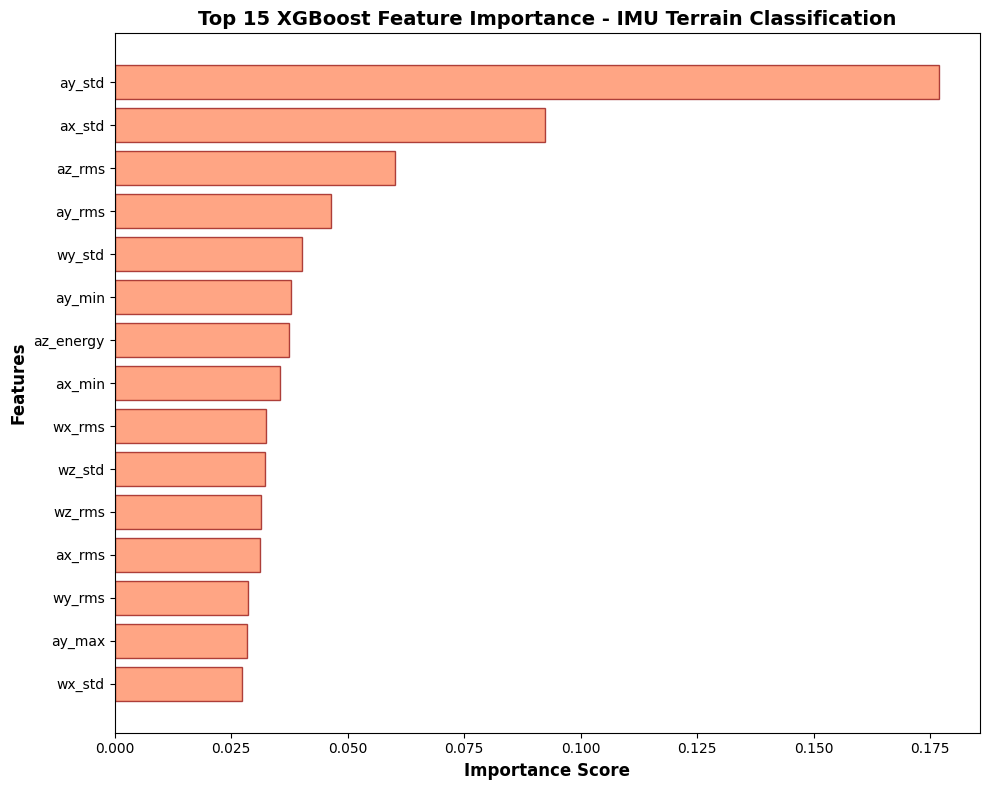

✓ Full feature importance chart saved as 'feature_importance_all_xgboost.png'


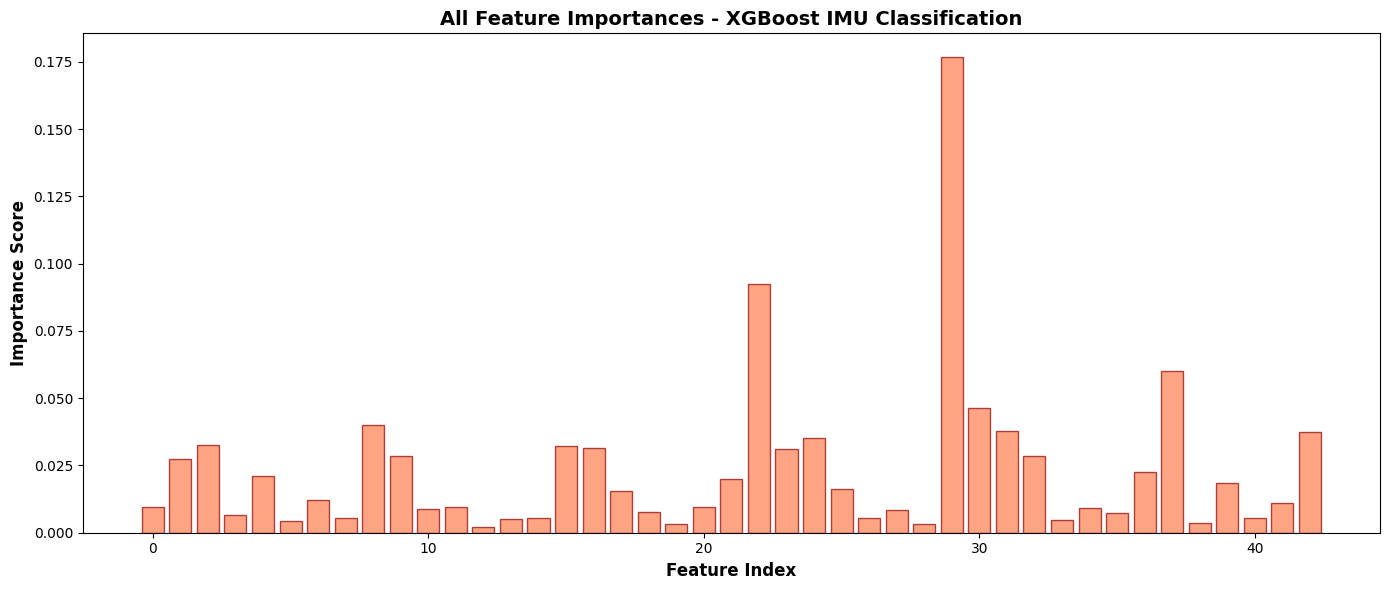

In [40]:

# ===============================
# CONFUSION MATRIX VISUALIZATION
# ===============================

cm = confusion_matrix(
    y_test,
    y_pred_test,
    labels=np.arange(len(TERRAINS))
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdYlGn",
    xticklabels=TERRAINS,
    yticklabels=TERRAINS,
    cbar_kws={"label": "Count"},
    square=True,
    linewidths=0.5,
    annot_kws={"fontsize": 10, "fontweight": "bold"}
)

plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("Actual Label", fontsize=12, fontweight="bold")
plt.title("Confusion Matrix - XGBoost IMU Terrain Classification", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_xgboost.png", dpi=300, bbox_inches="tight")
print("\n✓ Confusion matrix saved as 'confusion_matrix_xgboost.png'")
plt.show()


# ===============================
# FEATURE IMPORTANCE VISUALIZATION
# ===============================

print(f"\n{'='*60}")
print("FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*60}\n")

importances = xgb_model.feature_importances_
feature_names = [
    f"wx_{stat}" for stat in ["mean", "std", "rms", "min", "max", "skew", "kurt"]
] + [
    f"wy_{stat}" for stat in ["mean", "std", "rms", "min", "max", "skew", "kurt"]
] + [
    f"wz_{stat}" for stat in ["mean", "std", "rms", "min", "max", "skew", "kurt"]
] + [
    f"ax_{stat}" for stat in ["mean", "std", "rms", "min", "max", "skew", "kurt"]
] + [
    f"ay_{stat}" for stat in ["mean", "std", "rms", "min", "max", "skew", "kurt"]
] + [
    f"az_{stat}" for stat in ["mean", "std", "rms", "min", "max", "skew", "kurt"]
] + ["az_energy"]

# Create DataFrame for easier manipulation
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Top 15 features
top_15 = importance_df.tail(15)

print("Top 15 Most Important Features:")
print(top_15.to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(10, 8))
plt.barh(top_15['Feature'], top_15['Importance'], color='coral', edgecolor='darkred', alpha=0.7)
plt.xlabel("Importance Score", fontsize=12, fontweight="bold")
plt.ylabel("Features", fontsize=12, fontweight="bold")
plt.title("Top 15 XGBoost Feature Importance - IMU Terrain Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_top15_xgboost.png", dpi=300, bbox_inches="tight")
print("\n✓ Feature importance chart saved as 'feature_importance_top15_xgboost.png'")
plt.show()

# All features bar plot
plt.figure(figsize=(14, 6))
plt.bar(range(len(importances)), importances, color='coral', alpha=0.7, edgecolor='darkred')
plt.xlabel("Feature Index", fontsize=12, fontweight="bold")
plt.ylabel("Importance Score", fontsize=12, fontweight="bold")
plt.title("All Feature Importances - XGBoost IMU Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_all_xgboost.png", dpi=300, bbox_inches="tight")
print("✓ Full feature importance chart saved as 'feature_importance_all_xgboost.png'")
plt.show()



In [42]:

# ===============================
# SUMMARY REPORT
# ===============================

print(f"\n{'='*60}")
print("FINAL SUMMARY REPORT (XGBOOST)")
print(f"{'='*60}")
print(f"\nDataset:")
print(f"  Total Samples: {len(X)}")
print(f"  Features: {X.shape[1]}")
print(f"  Classes: {len(TERRAINS)}")
print(f"  Training/Test Split: 80/20")

print(f"\nModel Performance:")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print(f"  CV Mean Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

print(f"\nGeneralization:")
if abs(train_accuracy - test_accuracy) > 0.1:
    print(f"  Status: ⚠️  OVERFITTING (gap: {abs(train_accuracy - test_accuracy):.4f})")
elif abs(train_accuracy - test_accuracy) < 0.05:
    print(f"  Status: ✓ GOOD (gap: {abs(train_accuracy - test_accuracy):.4f})")
else:
    print(f"  Status: ✓ ACCEPTABLE (gap: {abs(train_accuracy - test_accuracy):.4f})")

print(f"\nOutput Files Generated:")
print(f"  1. confusion_matrix_xgboost.png - Confusion matrix heatmap")
print(f"  2. feature_importance_top15_xgboost.png - Top 15 features")
print(f"  3. feature_importance_all_xgboost.png - All features")

print(f"\n{'='*60}")
print("✓ XGBOOST EXECUTION COMPLETED SUCCESSFULLY!")
print(f"{'='*60}\n")


FINAL SUMMARY REPORT (XGBOOST)

Dataset:
  Total Samples: 453
  Features: 43
  Classes: 5
  Training/Test Split: 80/20

Model Performance:
  Test Accuracy: 0.9670
  CV Mean Accuracy: 0.9723 (±0.0088)

Generalization:
  Status: ✓ GOOD (gap: 0.0330)

Output Files Generated:
  1. confusion_matrix_xgboost.png - Confusion matrix heatmap
  2. feature_importance_top15_xgboost.png - Top 15 features
  3. feature_importance_all_xgboost.png - All features

✓ XGBOOST EXECUTION COMPLETED SUCCESSFULLY!

